<center><h1> ETI195 - Ética para Ciencia de Datos y Estadística </h1><center>
<center><h2> Taller Sumativo II: Sesgos, justicia, y discriminación <h2></center>

# `Instrucciones Generales`


## `Temas formales`

**Modalidad**: Grupos de 3 personas.

**Formato de entrega:** El trabajo debe entregarse a través de Canvas, tanto en formato Jupyter ejecutable (.ipynb) como en formato PDF.

**Formalidades de las respuestas:**
- Citas: APA 7.
- Se espera buena ortografía y redacción, con respuestas en tono académico.

## `Recomendaciones`

- Asistan a los talleres formativos, revisen los ejemplos de código y consulten sus dudas con sus ayudantes.

- **Lean la rúbrica antes de hacer su tarea.**

## `Integridad académica y uso de IA`

El uso de asistentes de IA sigue los lineamientos de integridad académica del curso, con las siguientes excepciones:

- Pueden usar IA para consultar por bugs y entender mejor el código.
- Pueden usar IA para generar las representaciones visuales que estimen convenientes.

Si tienen dudas sobre el uso de IA o la citación de código externo, no duden en preguntar. Pueden usar libremente los códigos de los talleres formativos. <3

---
## `Contexto`

La Encuesta de Caracterización Socioeconómica Nacional [CASEN 2024](https://observatorio.ministeriodesarrollosocial.gob.cl/encuesta-casen) cumple un rol fundamental en la toma de decisiones para la formulación de políticas sociales en Chile. Los organismos gubernamentales buscan estimar la realidad de la población, por lo que cualquier modelo predictivo construido a partir de estos datos tiene la capacidad de influir en la asignación de recursos y en la formulación de políticas públicas.

En ese sentido, un modelo que prediga la situación socioeconómica de la población puede transformarse en una herramienta con gran poder y grandes riegos.

Como científicos de datos, a menudo nos enfrentamos a este tipo de situaciones mediante dos preguntas: ¿cómo resolver automáticamente un problema de clasificación? Y, quizás más importante, ¿qué puede salir mal cuando ese modelo toma decisiones que afectan a personas?

En este taller entrenarán un modelo predictivo de pobreza multidimensional (`pobreza_multi`) utilizando el [dataset preprocesado](https://drive.google.com/file/d/15NMlO4BD-OB55uvfYWUSCh_ba4-zCzI8/view?usp=drive_link) de la encuesta [CASEN 2024](https://observatorio.ministeriodesarrollosocial.gob.cl/encuesta-casen).

El objetivo es detectar posibles sesgos en las predicciones, evaluar si el modelo es justo para distintos grupos de la población, aplicar técnicas de mitigación y discutir los riesgos de automatizar este tipo de problemas de clasificación.

---

## Parte 1

Lea la [**Metodología de Diseño Muestral CASEN 2024**](https://drive.google.com/file/d/1VafJ57Ta6_gwUM-8sir6PAw5DVuBh0rq/view?usp=sharing), específicamente la sección *Antecedentes y características generales del diseño*, y revise el [**libro de códigos de la base de datos CASEN 2024**](https://docs.google.com/spreadsheets/d/1x25URkqJy7Ncc61VEc75NE7XKFsrUHw5/edit?gid=937549388#gid=937549388) para entender las variables disponibles.

Antes de escribir una sola línea de código, lean los materiales de contexto mencionados anteriormente. Deben comprender por qué se levanta la encuesta CASEN, qué mide la variable `pobreza_multi`

### **RESPONDER**

1.  Discuta los objetivos de la encuenstra CASEN con referencias a la metodología y  para qué serviría entrenar  un clasificador automático de este tipo.

La encuesta Casen es uno de los principales instrumentos utilizados en Chile para conocer las condiciones socioeconómicas de los hogaress del país y realizar seguimiento a las políticas sociales. Según la "Metodología de Diseño Muestral Casen 2024", la encuesta busca conocer periódicamente la situación de los hogares y de la población, con foco en quienes se encuentran en situación de pobreza y a los grupos considerados prioritarios para políticas sociales. Para esto, recopila antecedentes relacionados con aspectos demográficos, esducación, salud, vivienda, trabajo e ingresos, lo que permite estimar la magnitud de pobreza, identificar carencias y analizar brechas entre distintos grupos sociales y territorios. Además, busca evaluar aspectos de política social como cobertura de programas y distribución del gasto social entre los hogares.

La variable *pobreza_multi*, corresponde a la situación de pobreza multidimensional. Es un enfoque que busca representar privaciones simultáneas en diferentes ámbitos de las condiciones de vida. La metodología aplicada el 2024 considera cinco dimensiones, siendo estas Educación, Salud, Trabajo y Seguridad Social, Vivienda y Entorno, y Redes y Cohesión Social. Cada una de estas dimensiones representa un 20% del índice y están compuestas por 4 indicadores con un 5% de ponderación cada uno. Un hogar se considera en situación de pobreza multidimensional cuando la suma ponderada de sus carencias es mayor al 20%, lo que es equivalente a presentar al menos cinco indicadores en carencia.

La medición tiene como objetivos obtener un diagnóstico mas comprensivo de la pobreza en Chile y constituir un instrumento útil para diseñar, implementar, monitorear y evaluar politicas públicas. Es por esto que entrenar un clasificador capaz de predecir la pobreza multidimensional podría servir como herramienta de análsisi para poder detectar patrones asociados a la pobreza multidimensional, estudiar que caracterísiticas permiten distinguir a la población con mas carencias o estudiar mecanismos de priorización.

Adempas, el uso de un clasificador presenta un riesgo importante. Un falso negativo correspondería a una persona u hogar que se encuentra en pobreza multidimensional pero que no es clasificado como pobre por el modelo.  Esto, podría producir errores o exclusión en las asignaciones de beneficios a personas que requieren apoyo.

Referencias:
* Ministerio de Desarrollo Social y Familia. (2026a). Metodología de diseño muestral Casen 2024. División Observatorio Social.
* Ministerio de Desarrollo Social y Familia. (2026b). Metodología de medición de la pobreza multidimensional en Chile: Actualización 2024. División Observatorio Social.


## Librerias y configuraciones

In [19]:
# imports iniciales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# sklearn - importa aquí las librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# aequitas
from aequitas.group import Group

# aif360
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.postprocessing.eq_odds_postprocessing import EqOddsPostprocessing
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset


import warnings
warnings.filterwarnings("ignore")

## Parte 2: Realice el preprocesamiento de los datos y entrene un árbol de decisión para predecir el nivel de pobreza multidimensional (pobreza_multi). Reporte el accuracy y la matriz de confusión sobre los datos de testeo.

*Puede reutilizar el jupyter o trabajar con el mismo jupyter de la entrega anterior, puede entregar una carpeta con ambos jupyter y funciones compartidas*

### Indicaciones

- El preprocesamiento debe incluir al menos: manejo de valores faltantes, codificación de variables categóricas, normalización de variables númericas y tratamiento de valores extremos

- Utilice random_state o semillas donde corresponda para garantizar la reproducibilidad de los resultados.

- La clase pobreza_multi está desbalanceada. Investigue el argumento class_weight='balanced' de sklearn para manejar este problema y aplíquelo si lo considera pertinente.


### **RESPONDER**

2.1 Explique y justifique los pasos del preprocesamiento.

2.2 ¿Podemos concluír con esto que el modelo tiene el mismo rendimiento para todos los grupos demográficos?


In [20]:
df_casen = pd.read_csv("data/casen_2024.csv")
print("Dimensiones: ", df_casen.shape)

display(df_casen.head())

print("\ndistribución de pobreza_multi: ")
print(df_casen["pobreza_multi"].value_counts())

print("\nPorcentaje:")
print(df_casen["pobreza_multi"].value_counts(normalize=True) * 100)


Dimensiones:  (212471, 42)


,area,p1,p2,p3,p4,p9,tot_per_h,edad,sexo,ind_hacina,...,v22,v23,v24,v24b,v27a,v27b,v29b,os1,trans,pobreza_multi
0,Urbano,Casa acceso directo,3,3,3,2,2,62,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,40000.0,1.0,1.0,1.0,Heterosexual,No,No pobre
1,Urbano,Casa acceso directo,3,3,3,2,2,92,Mujer,1,...,Llave dentro vivienda,1,Red pública medidor propio,40000.0,1.0,1.0,1.0,Heterosexual,No,No pobre
2,Urbano,Casa acceso directo,3,3,4,4,4,61,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre
3,Urbano,Casa acceso directo,3,3,4,4,4,61,Mujer,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre
4,Urbano,Casa acceso directo,3,3,4,4,4,32,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre



distribución de pobreza_multi: 
pobreza_multi
No pobre    174979
Pobre        37492
Name: count, dtype: int64

Porcentaje:
pobreza_multi
No pobre    82.354298
Pobre       17.645702
Name: proportion, dtype: float64


In [21]:
y = df_casen["pobreza_multi"].map({
    "No pobre": 0,
    "Pobre": 1
})

X = df_casen.drop(columns=["pobreza_multi"]).copy()

print(y.value_counts())

pobreza_multi
0    174979
1     37492
Name: count, dtype: int64


In [22]:
columnas_categoricas_numericas = [
    "p2",
    "p3",
    "p4",
    "ind_hacina",
    "o1",
    "h7e",
    "h7f",
    "r14",
    "r17a",
    "r17b",
    "r17c",
    "v3",
    "v5",
    "v23"
]

for columna in columnas_categoricas_numericas:
    X[columna] = X[columna].astype("string")

In [23]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Copias que modificaremos
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño test:", X_test.shape)

print("\nDistribución entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución test:")
print(y_test.value_counts(normalize=True))

Tamaño entrenamiento: (169976, 41)
Tamaño test: (42495, 41)

Distribución entrenamiento:
pobreza_multi
0    0.823546
1    0.176454
Name: proportion, dtype: float64

Distribución test:
pobreza_multi
0    0.823532
1    0.176468
Name: proportion, dtype: float64


In [24]:
# Revisa si hay valores
nulos = df_casen.isnull().sum()

print(
    nulos[nulos > 0]
)

Series([], dtype: int64)


In [25]:
# Tratamiento por si igualmente hubieran datos faltantes
columnas_numericas = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

columnas_categoricas = [
    columna
    for columna in X_train.columns
    if columna not in columnas_numericas
]

print("Variables numéricas:")
print(columnas_numericas)

print("\nCantidad de variables categóricas:")
print(len(columnas_categoricas))

Variables numéricas:
['p9', 'tot_per_h', 'edad', 'v24b', 'v27a', 'v27b', 'v29b']

Cantidad de variables categóricas:
34


In [26]:
# Imputación preventiva
# Variables numéricas: mediana
for columna in columnas_numericas:

    mediana = X_train[columna].median()

    X_train[columna] = X_train[columna].fillna(mediana)
    X_test[columna] = X_test[columna].fillna(mediana)


# Variables categóricas: moda
for columna in columnas_categoricas:

    moda = X_train[columna].mode(dropna=True)

    if len(moda) > 0:
        valor_reemplazo = moda.iloc[0]
    else:
        valor_reemplazo = "Sin dato"

    X_train[columna] = X_train[columna].fillna(
        valor_reemplazo
    )

    X_test[columna] = X_test[columna].fillna(
        valor_reemplazo
    )

In [27]:
#Tratamiento de valores extremos
# Se utiliza el rango intercuartílico (IQR)

limites_outliers = {}

for columna in columnas_numericas:

    q1 = X_train[columna].quantile(0.25)
    q3 = X_train[columna].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    limites_outliers[columna] = (
        limite_inferior,
        limite_superior
    )

    # Si IQR = 0, no hacemos clipping
    if iqr > 0:

        X_train[columna] = X_train[columna].clip(
            limite_inferior,
            limite_superior
        )

        X_test[columna] = X_test[columna].clip(
            limite_inferior,
            limite_superior
        )

In [28]:
# Normalización
scaler = MinMaxScaler()

X_train[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)

X_test[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)


In [29]:
# Codificación de variables categóricas
# Se aplica one-hot encodeing

X_train = pd.get_dummies(
    X_train,
    columns=columnas_categoricas,
    dtype=np.uint8
)

X_test = pd.get_dummies(
    X_test,
    columns=columnas_categoricas,
    dtype=np.uint8
)



In [30]:
# Iguala columnas en caso de que una categoría aparezca en entrenamiento
# y no en test

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("Dimensiones X_train:", X_train.shape)
print("Dimensiones X_test:", X_test.shape)

Dimensiones X_train: (169976, 141)
Dimensiones X_test: (42495, 141)


In [34]:
# Entrenamiento del arbol de decisión
# Usa class_weight="balanced", por el desbalance de pobreza_multi
modelo_arbol = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

modelo_arbol.fit(
    X_train,
    y_train
)

#Generamos las predicciones
y_pred = modelo_arbol.predict(
    X_test
)

In [35]:
#Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 0.9359
Accuracy: 93.59%


In [36]:
# Matriz de confusión
matriz_confusion = confusion_matrix(
    y_test,
    y_pred
)

print(matriz_confusion)

[[33674  1322]
 [ 1403  6096]]


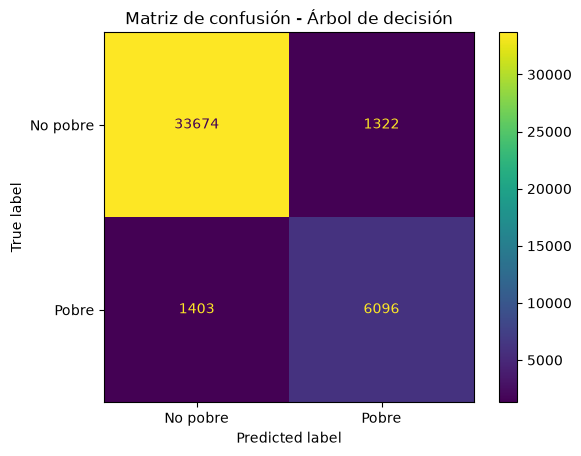

In [38]:
# Gráfico
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=[
        "No pobre",
        "Pobre"
    ]
).plot()

plt.title(
    "Matriz de confusión - Árbol de decisión"
)

plt.show()

Interpretación:
33.635 = No pobres correctamente clasificados
 1.361 = No pobres clasificados como pobres

 1.417 = Pobres clasificados como no pobres --------- OJO CON ESTO, ES IMPORTANTE
 6.082 = Pobres correctamente clasificados

In [39]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No pobre",
            "Pobre"
        ]
    )
)

              precision    recall  f1-score   support

    No pobre       0.96      0.96      0.96     34996
       Pobre       0.82      0.81      0.82      7499

    accuracy                           0.94     42495
   macro avg       0.89      0.89      0.89     42495
weighted avg       0.94      0.94      0.94     42495



## Parte 3: Evalúe las predicciones del modelo mediante las métricas de Fairness de Aequitas.

### **Indicaciones**

Considere como posibles atributos demográficos sensibles: genero, r3 (pertenencia a pueblo indígena), os1 (orientación sexual) y edad_cat; o bien atributos asociados a posibles discapacidades (revise el libro de códigos): h7e y h7f.

**Paso 1: Binarice las variables sensibles.**
Aequitas requiere que todas las variables sensibles estén binarizadas en grupos privilegiado / no privilegiado. Para variables con más de dos categorías, cree una columna auxiliar que agrupe las categorías y justifique su decisión.

**Paso 2: Elija al menos 2 atributos sensibles y defina sus grupos.**

Ejemplos de posibles agrupaciones, y grupos considere que puede elegir sus propias categorizaciones de privilegio y los grupos que estime.:

| Atributo | Grupo | Categoría |
|---|---|---|
| r3 | Privilegiado | no indígena |
| r3 | No privilegiado | indígena |
| os1 | Privilegiado | heterosexual |
| os1 | No privilegiado | otras orientaciones |
| edad_cat | Privilegiado | *(a definir según los intervalos que usted cree, justificando la elección)* |
| edad_cat | No privilegiado | *(a definir según los intervalos que usted cree, justificando la elección)* |

o, asociados a discapacidad:

| Atributo | Grupo | Categoría |
|---|---|---|
| h7e | Privilegiado | 1. No, ninguna dificultad |
| h7e | No privilegiado | las demás categorías |
| h7f | Privilegiado | 1. No, ninguna dificultad |
| h7f | No privilegiado | las demás categorías |

Pueden

**Paso 3: Reporte las métricas.**
Reporte las métricas de *False Negative Rate Parity* y *False Discovery Rate Parity* para los atributos y grupos definidos.

### **RESPONDER**

Pregunta 3.1 Explique los resultados obtenidos.

Pregunta 3.2 ¿Cuán justas se pueden considerar las predicciones del modelo para cada grupo? ¿Cómo relacionaría esto con los contenidos del curso?

In [55]:
# ============================================================
# PARTE 3 - FAIRNESS CON AEQUITAS
# ============================================================

from aequitas.group import Group
from aequitas.bias import Bias


# Recuperamos los atributos originales de las mismas
# personas utilizadas en el conjunto de test.

assert X_test_raw.index.equals(y_test.index)
assert X_test.index.equals(y_test.index)
assert y_test.index.is_unique
assert len(y_pred) == len(y_test)

datos_fairness = pd.DataFrame(
    index=y_test.index
)

# Predicción y etiqueta real
datos_fairness["score"] = np.asarray(
    y_pred,
    dtype=int
)

datos_fairness["label_value"] = (
    y_test.astype(int)
)


# ============================================================
# PERTENENCIA INDÍGENA
# ============================================================

datos_fairness["pertenencia_indigena"] = (
    X_test_raw["r3"]
    .astype("string")
    .str.strip()
    .map({
        "No indígena": "No indigena",
        "Indígena": "Indigena"
    })
)


# ============================================================
# DIFICULTAD PARA EL CUIDADO PERSONAL
# ============================================================

h7e_test = pd.to_numeric(
    X_test_raw["h7e"],
    errors="coerce"
)

datos_fairness["cuidado_personal"] = (
    h7e_test.map({
        1: "Sin dificultad",
        2: "Con dificultad",
        3: "Con dificultad",
        4: "Con dificultad"
    })
)


# Grupos de referencia
grupos_referencia = {
    "pertenencia_indigena": "No indigena",
    "cuidado_personal": "Sin dificultad"
}


# Distribuciones
for atributo in grupos_referencia:

    print(
        f"\n{atributo}: distribución en test"
    )

    print(
        datos_fairness[
            atributo
        ].value_counts(
            dropna=False
        )
    )


pertenencia_indigena: distribución en test
pertenencia_indigena
No indigena    36526
Indigena        5969
Name: count, dtype: int64

cuidado_personal: distribución en test
cuidado_personal
Sin dificultad    40850
Con dificultad     1645
Name: count, dtype: int64


In [56]:
tablas_fairness = []

for atributo, referencia in grupos_referencia.items():

    # Cada atributo se evalúa por separado.
    datos_atributo = datos_fairness[
        [
            "score",
            "label_value",
            atributo
        ]
    ].dropna(
        subset=[atributo]
    ).copy()


    print(
        f"{atributo}: "
        f"{len(datos_atributo)} evaluados; "
        f"{len(datos_fairness) - len(datos_atributo)} "
        "excluidos"
    )


    # Aequitas requiere que el atributo sea categórico.
    datos_atributo[atributo] = (
        datos_atributo[
            atributo
        ].astype(str)
    )


    # Verificaciones
    assert referencia in (
        datos_atributo[
            atributo
        ].unique()
    )

    assert (
        datos_atributo[
            atributo
        ].nunique()
        == 2
    )


    # Métricas por grupo
    tabla_grupos, _ = (
        Group().get_crosstabs(
            datos_atributo
        )
    )


    # Disparidades respecto al grupo de referencia
    tabla_disparidades = (
        Bias().get_disparity_predefined_groups(
            tabla_grupos,
            original_df=datos_atributo,
            ref_groups_dict={
                atributo: referencia
            },
            input_group_metrics=[
                "fnr",
                "fdr"
            ],
            check_significance=False,
            fill_divbyzero=None
        )
    )

    tablas_fairness.append(
        tabla_disparidades
    )


# Unimos resultados
resultados_fairness = pd.concat(
    tablas_fairness,
    ignore_index=True
)


columnas_resultado = [
    "attribute_name",
    "attribute_value",
    "group_size",
    "tp",
    "fn",
    "fp",
    "tn",
    "fnr",
    "fdr",
    "fnr_disparity",
    "fdr_disparity"
]


resumen_fairness = (
    resultados_fairness[
        columnas_resultado
    ].copy()
)

display(
    resumen_fairness.round(4)
)

pertenencia_indigena: 42495 evaluados; 0 excluidos
cuidado_personal: 42495 evaluados; 0 excluidos


,attribute_name,attribute_value,group_size,tp,fn,fp,tn,fnr,fdr,fnr_disparity,fdr_disparity
0,pertenencia_indigena,Indigena,5969,1150,247,218,4354,0.1768,0.1594,0.9333,0.8733
1,pertenencia_indigena,No indigena,36526,4946,1156,1104,29320,0.1894,0.1825,1.0000,1.0000
2,cuidado_personal,Con dificultad,1645,301,136,101,1107,0.3112,0.2512,1.7346,1.4437
3,cuidado_personal,Sin dificultad,40850,5795,1267,1221,32567,0.1794,0.1740,1.0000,1.0000


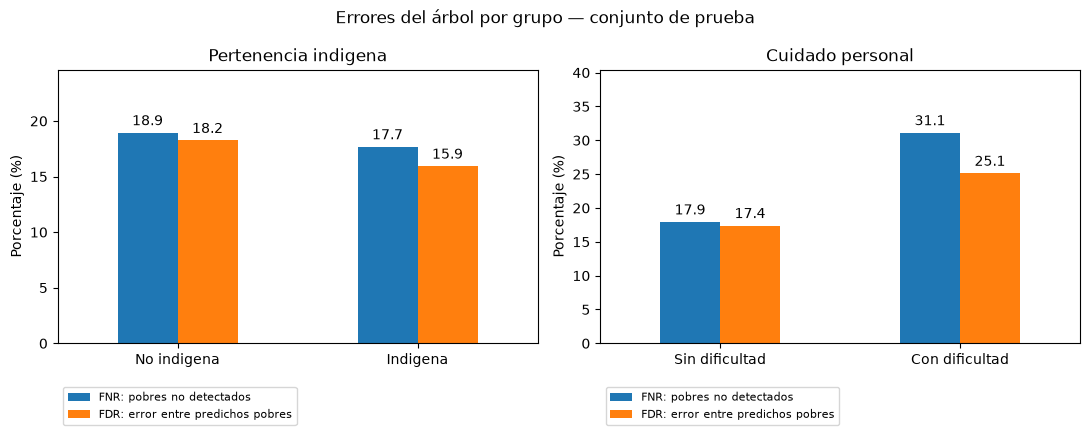

In [58]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5)
)

for ax, (atributo, referencia) in zip(
    axes,
    grupos_referencia.items()
):

    tabla = resumen_fairness.loc[
        resumen_fairness[
            "attribute_name"
        ].eq(atributo)
    ].set_index(
        "attribute_value"
    )

    orden = [
        referencia
    ] + [
        grupo
        for grupo in tabla.index
        if grupo != referencia
    ]

    tasas = tabla.loc[
        orden,
        [
            "fnr",
            "fdr"
        ]
    ].mul(100)

    tasas.columns = [
        "FNR: pobres no detectados",
        "FDR: error entre predichos pobres"
    ]

    tasas.plot.bar(
        ax=ax,
        rot=0
    )

    ax.set_title(
        atributo.replace(
            "_",
            " "
        ).capitalize()
    )

    ax.set_ylabel(
        "Porcentaje (%)"
    )

    ax.set_xlabel("")

    ax.set_ylim(
        0,
        tasas.max().max() * 1.30
    )

    for contenedor in ax.containers:
        ax.bar_label(
            contenedor,
            fmt="%.1f",
            padding=3
        )

    ax.legend(
        fontsize=8,
        loc="upper left",
        bbox_to_anchor=(0, -0.14)
    )

fig.suptitle(
    "Errores del árbol por grupo — conjunto de prueba"
)

plt.tight_layout()
plt.show()

## Respuesta 3.1

Las predicciones del árbol fueron evaluadas sobre las 42.495 observaciones del conjunto de prueba, considerando la pobreza multidimensional como clase positiva. Se analizaron dos atributos sensibles: pertenencia indígena (r3) y dificultad para el cuidado personal (h7e). La False Negative Rate (FNR) representa la proporción de personas realmente pobres que fueron clasificadas incorrectamente como no pobres, mientras que la False Discovery Rate (FDR) corresponde a la proporción de personas clasificadas como pobres que realmente pertenecían a la clase no pobre.
Para pertenencia indígena, las personas indígenas presentaron una FNR de 17,68 %, mientras que en el grupo no indígena fue de 18,94 %. La razón de disparidad fue 0,933, lo que indica que la FNR del grupo indígena fue aproximadamente un 6,7 % menor que la del grupo utilizado como referencia. La FDR fue de 15,94 % para las personas indígenas y de 18,25 % para las no indígenas, con una razón de 0,873. Las diferencias absolutas entre ambos grupos fueron, por tanto, relativamente pequeñas en estas dos métricas.
Las diferencias fueron más marcadas en el atributo de cuidado personal. Entre las personas que presentan alguna dificultad, la FNR fue de 31,12 %, frente a un 17,94 % entre quienes no presentan dificultades. La razón de FNR fue 1,735, lo que significa que la tasa de falsos negativos fue aproximadamente un 73,5 % mayor en el grupo con dificultad.
Asimismo, la FDR fue de 25,12 % para las personas con dificultad y de 17,40 % para quienes no presentan dificultad, con una razón de 1,444. Esto representa una FDR aproximadamente un 44,4 % superior. Por lo tanto, las mayores diferencias de rendimiento aparecen en el atributo relacionado con dificultades para el cuidado personal.

# Respuesta 3.2

Las predicciones del árbol fueron evaluadas sobre las 42.495 observaciones del conjunto de prueba, considerando la pobreza multidimensional como clase positiva. Se analizaron dos atributos sensibles: pertenencia indígena (r3) y dificultad para el cuidado personal (h7e). La False Negative Rate (FNR) representa la proporción de personas realmente pobres que fueron clasificadas incorrectamente como no pobres, mientras que la False Discovery Rate (FDR) corresponde a la proporción de personas clasificadas como pobres que realmente pertenecían a la clase no pobre.
Para pertenencia indígena, las personas indígenas presentaron una FNR de 17,68 %, mientras que en el grupo no indígena fue de 18,94 %. La razón de disparidad fue 0,933, lo que indica que la FNR del grupo indígena fue aproximadamente un 6,7 % menor que la del grupo utilizado como referencia. La FDR fue de 15,94 % para las personas indígenas y de 18,25 % para las no indígenas, con una razón de 0,873. Las diferencias absolutas entre ambos grupos fueron, por tanto, relativamente pequeñas en estas dos métricas.
Las diferencias fueron más marcadas en el atributo de cuidado personal. Entre las personas que presentan alguna dificultad, la FNR fue de 31,12 %, frente a un 17,94 % entre quienes no presentan dificultades. La razón de FNR fue 1,735, lo que significa que la tasa de falsos negativos fue aproximadamente un 73,5 % mayor en el grupo con dificultad.
Asimismo, la FDR fue de 25,12 % para las personas con dificultad y de 17,40 % para quienes no presentan dificultad, con una razón de 1,444. Esto representa una FDR aproximadamente un 44,4 % superior. Por lo tanto, las mayores diferencias de rendimiento aparecen en el atributo relacionado con dificultades para el cuidado personal.

## Parte 4: Aplique el algoritmo EqOddsPostProcessing sobre las predicciones del modelo de la pregunta 1. Obtenga las predicciones modificadas y evalúelas.

#### Indicaciones:

- Obtenga tanto las instancias de BinaryLabelDatasetMetric como de ClassificationMetric y calcule al menos una métrica de Fairness.

### **RESPONDER**

pregunta 4.1: comentar brevemente los resultados obtenidos, y evaluar los cambios en las métricas de Fairness. Reflexionar sobre los beneficios y limitaciones


In [59]:
### codigo aquí
from aif360.datasets import BinaryLabelDataset

from aif360.metrics import (
    BinaryLabelDatasetMetric,
    ClassificationMetric
)

from aif360.algorithms.postprocessing import (
    EqOddsPostprocessing
)


# ============================================================
# DIVISIÓN CALIBRACIÓN / EVALUACIÓN
# ============================================================

datos_p4 = datos_fairness.dropna(
    subset=list(
        grupos_referencia
    )
).copy()


print(
    "Excluidos por atributos desconocidos:",
    len(datos_fairness) - len(datos_p4)
)


# Estratificación conjunta
estratos_p4 = (
    datos_p4[
        "label_value"
    ].astype(str)
    + "|"
    + datos_p4[
        "pertenencia_indigena"
    ].astype(str)
    + "|"
    + datos_p4[
        "cuidado_personal"
    ].astype(str)
)


assert (
    estratos_p4.value_counts().min()
    >= 2
)


indices_cal, indices_eval = train_test_split(
    datos_p4.index,
    test_size=0.5,
    random_state=42,
    stratify=estratos_p4
)


assert set(indices_cal).isdisjoint(
    indices_eval
)


print(
    "Calibración:",
    len(indices_cal),
    "| Evaluación:",
    len(indices_eval)
)

Excluidos por atributos desconocidos: 0
Calibración: 21247 | Evaluación: 21248


In [60]:
def crear_dataset_p4(
    datos,
    atributo,
    referencia
):

    tabla = pd.DataFrame(
        index=datos.index
    )

    # 1 = grupo de referencia
    # 0 = grupo de comparación
    tabla["grupo"] = (
        datos[
            atributo
        ]
        .eq(referencia)
        .astype(float)
    )

    tabla["pobreza_multi"] = (
        datos[
            "label_value"
        ].astype(float)
    )


    # Etiquetas reales
    real = BinaryLabelDataset(
        df=tabla,
        label_names=[
            "pobreza_multi"
        ],
        protected_attribute_names=[
            "grupo"
        ],
        favorable_label=1.0,
        unfavorable_label=0.0,
        privileged_protected_attributes=[
            np.array([1.0])
        ],
        unprivileged_protected_attributes=[
            np.array([0.0])
        ]
    )


    # Predicciones del árbol
    pred = real.copy(
        deepcopy=True
    )

    pred.labels = (
        datos[
            "score"
        ]
        .to_numpy(
            dtype=float
        )
        .reshape(-1, 1)
    )

    pred.scores = (
        pred.labels.copy()
    )


    return real, pred

In [61]:
privilegiados_p4 = [
    {"grupo": 1.0}
]

no_privilegiados_p4 = [
    {"grupo": 0.0}
]


resultados_p4 = []
tasas_p4 = []

ajustes_p4 = {}
predicciones_p4 = {}
metricas_p4 = {}


for atributo, referencia in (
    grupos_referencia.items()
):

    # Datos de calibración
    real_cal, pred_cal = crear_dataset_p4(
        datos_p4.loc[
            indices_cal
        ],
        atributo,
        referencia
    )

    # Datos de evaluación
    real_eval, pred_eval = crear_dataset_p4(
        datos_p4.loc[
            indices_eval
        ],
        atributo,
        referencia
    )


    # ========================================================
    # EQODDS
    # ========================================================

    ajuste = EqOddsPostprocessing(
        unprivileged_groups=(
            no_privilegiados_p4
        ),
        privileged_groups=(
            privilegiados_p4
        ),
        seed=42
    )


    ajuste.fit(
        real_cal,
        pred_cal
    )


    # Predicciones modificadas
    pred_ajustada = ajuste.predict(
        pred_eval
    )


    ajustes_p4[
        atributo
    ] = ajuste


    predicciones_p4[
        atributo
    ] = pd.Series(
        pred_ajustada.labels
        .ravel()
        .astype(int),
        index=indices_eval
    )


    # ========================================================
    # ANTES Y DESPUÉS
    # ========================================================

    for etapa, pred in [
        ("Antes", pred_eval),
        ("Despues", pred_ajustada)
    ]:

        # BinaryLabelDatasetMetric
        met_datos = (
            BinaryLabelDatasetMetric(
                pred,
                unprivileged_groups=(
                    no_privilegiados_p4
                ),
                privileged_groups=(
                    privilegiados_p4
                )
            )
        )


        # ClassificationMetric
        met_clas = (
            ClassificationMetric(
                real_eval,
                pred,
                unprivileged_groups=(
                    no_privilegiados_p4
                ),
                privileged_groups=(
                    privilegiados_p4
                )
            )
        )


        metricas_p4[
            (atributo, etapa)
        ] = (
            met_datos,
            met_clas
        )


        # Brechas
        brecha_tpr = (
            met_clas.true_positive_rate(
                privileged=False
            )
            -
            met_clas.true_positive_rate(
                privileged=True
            )
        )

        brecha_fpr = (
            met_clas.false_positive_rate(
                privileged=False
            )
            -
            met_clas.false_positive_rate(
                privileged=True
            )
        )


        resultados_p4.append({

            "atributo":
                atributo,

            "etapa":
                etapa,

            "accuracy":
                met_clas.accuracy(),

            "equal_opportunity_difference":
                met_clas.equal_opportunity_difference(),

            "brecha_FPR":
                brecha_fpr,

            "max_brecha_EO":
                max(
                    abs(brecha_tpr),
                    abs(brecha_fpr)
                ),

            "diferencia_paridad_estadistica":
                met_datos.statistical_parity_difference(),

            "cambios_prediccion":
                int(
                    np.sum(
                        pred.labels
                        !=
                        pred_eval.labels
                    )
                )
        })


        # Tasas por grupo
        for es_referencia, nombre in [
            (
                True,
                referencia
            ),
            (
                False,
                "Grupo de comparación"
            )
        ]:

            if not es_referencia:

                nombre = (
                    datos_p4.loc[
                        datos_p4[
                            atributo
                        ].ne(
                            referencia
                        ),
                        atributo
                    ]
                    .iloc[0]
                )


            mascara = (
                real_eval
                .protected_attributes
                .ravel()
                ==
                int(
                    es_referencia
                )
            )


            tasas_p4.append({

                "atributo":
                    atributo,

                "etapa":
                    etapa,

                "grupo":
                    nombre,

                "n":
                    int(
                        mascara.sum()
                    ),

                "FNR":
                    met_clas.false_negative_rate(
                        privileged=es_referencia
                    ),

                "FPR":
                    met_clas.false_positive_rate(
                        privileged=es_referencia
                    ),

                "FDR":
                    met_clas.false_discovery_rate(
                        privileged=es_referencia
                    )
            })


comparacion_p4 = pd.DataFrame(
    resultados_p4
)

tasas_grupos_p4 = pd.DataFrame(
    tasas_p4
)


display(
    comparacion_p4.round(4)
)

display(
    tasas_grupos_p4.round(4)
)

,atributo,etapa,accuracy,equal_opportunity_difference,brecha_FPR,max_brecha_EO,diferencia_paridad_estadistica,cambios_prediccion
0,pertenencia_indigena,Antes,0.9373,0.0484,0.0090,0.0484,0.0702,0
1,pertenencia_indigena,Despues,0.9240,0.0724,-0.0048,0.0724,0.0628,334
2,cuidado_personal,Antes,0.9373,-0.1351,0.0424,0.1351,0.0687,0
3,cuidado_personal,Despues,0.8730,0.0006,-0.0101,0.0101,0.0488,1642


,atributo,etapa,grupo,n,FNR,FPR,FDR
0,pertenencia_indigena,Antes,No indigena,18264,0.1845,0.0374,0.1861
1,pertenencia_indigena,Antes,Indigena,2984,0.1361,0.0464,0.1495
2,pertenencia_indigena,Despues,No indigena,18264,0.2085,0.0511,0.2437
3,pertenencia_indigena,Despues,Indigena,2984,0.1361,0.0464,0.1495
4,cuidado_personal,Antes,Sin dificultad,20426,0.1677,0.0371,0.1758
5,cuidado_personal,Antes,Con dificultad,822,0.3028,0.0795,0.2400
6,cuidado_personal,Despues,Sin dificultad,20426,0.3033,0.0896,0.3810
7,cuidado_personal,Despues,Con dificultad,822,0.3028,0.0795,0.2400


## Respuesta 4.1

EqOddsPostprocessing fue ajustado utilizando 21.247 observaciones de calibración y posteriormente evaluado sobre otras 21.248 observaciones. Por este motivo, las métricas de esta sección corresponden únicamente al subconjunto de evaluación y no deben confundirse con las métricas calculadas sobre las 42.495 observaciones utilizadas en la Parte 3.
Para pertenencia indígena, el algoritmo no produjo una mejora en Equalized Odds sobre el conjunto de evaluación. El accuracy disminuyó desde 93,73 % hasta 92,40 %, mientras que la máxima brecha entre TPR y FPR aumentó desde 4,84 hasta 7,24 puntos porcentuales. La Equal Opportunity Difference pasó de 0,0484 a 0,0724. Por lo tanto, en este atributo el posprocesamiento no consiguió simultáneamente reducir la diferencia entre grupos y mantener el rendimiento predictivo.
En cambio, para dificultad en el cuidado personal se produjo una reducción importante de las diferencias entre grupos. La máxima brecha de Equalized Odds disminuyó desde 13,51 hasta 1,01 puntos porcentuales y la Equal Opportunity Difference pasó de -0,1351 a 0,0006, valor muy cercano a cero. Sin embargo, esta mejora estuvo acompañada de una disminución del accuracy desde 93,73 % hasta 87,30 %.
El análisis de las tasas de error muestra además que esta mayor paridad no se obtuvo mejorando sustancialmente el rendimiento del grupo con dificultad. Antes del ajuste, su FNR era de 30,28 %, mientras que después se mantuvo en 30,28 %. En cambio, la FNR del grupo sin dificultad aumentó desde 16,77 % hasta 30,33 %. Por lo tanto, en esta ejecución la igualdad entre ambos grupos se alcanzó principalmente deteriorando el desempeño del grupo que originalmente presentaba la menor tasa de falsos negativos.
Este resultado muestra una limitación importante de las métricas de fairness: una menor diferencia entre grupos no necesariamente significa que las predicciones hayan mejorado para el grupo inicialmente más afectado. La paridad puede alcanzarse haciendo que ambos grupos tengan tasas de error similares, incluso si esto implica aumentar los errores de uno de ellos.
Una ventaja de EqOddsPostprocessing es que permite intervenir sobre las predicciones de un modelo ya entrenado sin modificar el conjunto de entrenamiento ni volver a ajustar el árbol. Sin embargo, al actuar únicamente sobre las predicciones finales, no corrige las causas que puedan haber originado las diferencias de rendimiento en los datos o en el proceso de aprendizaje.
Además, Equalized Odds busca igualar específicamente TPR y FPR, pero no garantiza simultáneamente paridad de FDR, paridad estadística u otros criterios de fairness. Los dos atributos sensibles fueron tratados mediante ajustes independientes, por lo que tampoco puede afirmarse que exista una única versión del modelo que resuelva simultáneamente las disparidades relacionadas con pertenencia indígena y dificultad para el cuidado personal.
En un posible contexto de apoyo a decisiones sociales, el costo de aumentar los falsos negativos resulta especialmente relevante, ya que corresponde a personas realmente pobres que el sistema clasificaría como no pobres. Por ello, la selección de una técnica de mitigación no debería basarse únicamente en reducir una métrica de disparidad, sino considerar conjuntamente rendimiento global, distribución de errores y consecuencias para los distintos grupos.

## **Parte 5** (bonus +5 decimas) :  

Aplique el algoritmo de Reweighing sobre los datos de entrenamiento. Compare las métricas de Fairness para los datos de entrenamiento antes y después de aplicar Reweighing.

Luego, entrene un Arbol de decisión utilizando los datos de entrenamiento modificados y obtenga las métricas de Fairness de las predicciones de dicho modelo.

Analice cómo varió el *accuracy* del modelo respecto al original y las métricas de Fairness y reflexione sobre las implicancias sociales de estas decisiones.

### Indicaciones:
Puedes considerar los grupos priviligiados/no priviligiados mencionados en la parte 3. Considere al menos 2.

In [33]:
### codigo aquí